In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

In [2]:
import Xm

In [3]:
#xm=Xm.Xm(XmlFile='../testdata/FW.XML') # "C:\3S\Modelle\MVV_FW.XML"
xm=Xm.Xm(XmlFile=r'C:\3S\Modelle\MVV_FW.XML')

=== LFKT ===

In [4]:
xm.vLFKT.head(5)

,NAME,BESCHREIBUNG,LF,LF_min,LF_max,INTPOL,ZEITOPTION,pk_x
0,LfTh,Beschreibung Tabelle,1,1,1,0,0,4843828177877341965
1,LFKT,Lastgang f(LFT),1,1,1,0,0,5416134108033797245


In [5]:
xm.vLFKT.dtypes

NAME            object
BESCHREIBUNG    object
LF               int64
LF_min           int64
LF_max           int64
INTPOL          object
ZEITOPTION      object
pk_x            object
dtype: object

=== FWVB ===

In [6]:
xm.vFWVB[['VTYP','W0','LFK','TVL0','TRS0','W','INDTR','TRSK','NAME']].head(5)

,VTYP,W0,LFK,TVL0,TRS0,W,INDTR,TRSK,NAME
0,14,28.3694,1,130,60,28.3694,1,60,LfTh
1,14,11.0988,1,130,60,11.0988,1,60,LfTh
2,14,10.1879,1,130,60,10.1879,1,60,LfTh
3,14,14.5338,1,130,60,14.5338,1,60,LfTh
4,14,27.2216,1,130,60,27.2216,1,60,LfTh


In [7]:
xm.vFWVB[['VTYP','W0','LFK','TVL0','TRS0','W','INDTR','TRSK','NAME']].dtypes

VTYP       int64
W0       float64
LFK        int64
TVL0       int64
TRS0       int64
W        float64
INDTR      int64
TRSK       int64
NAME      object
dtype: object

In [8]:
#%matplotlib inline
import matplotlib.pyplot as plt

In [9]:
plt.close('all')
plt.figure()

In [10]:
vFWVB_h=xm.vFWVB[['W0']]

In [11]:
vFWVB_h.dtypes

W0    float64
dtype: object

In [12]:
vFWVB_h.plot.hist(bins=10
                  ,range=(0,240)
                 )

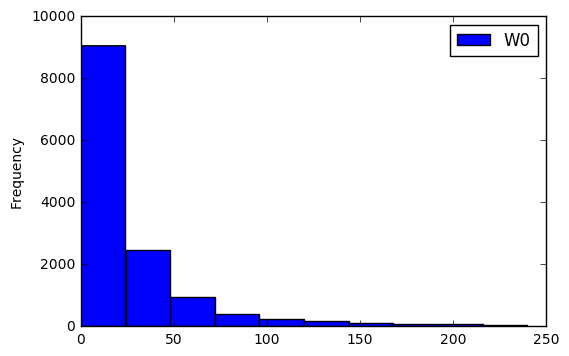

In [13]:
plt.show()

# FWVB

Kundenanlagen Anschlusswerte W0 sind typischerweise nicht normarlverteilt.

In [290]:
xm.vFWVB.W0.describe()

count     13930.000000
mean         65.288680
std        1448.312563
min           0.000000
25%           8.000000
50%          14.989400
75%          34.476625
max      150000.000000
Name: W0, dtype: float64

In [292]:
xm.vFWVB.W0.sum()

909471.3186699954

In [295]:
xm.vFWVB.W0.median()

14.9894

In [524]:
xm.vFWVB.W0[xm.vFWVB.W0 <= xm.vFWVB.W0.mean()+xm.vFWVB.W0.std()].count()/xm.vFWVB.W0.count()

0.99720028715003595

## Kategorien
Eine W0-äquidistante Kategorisierung von FWVB ist daher i.d.R. nicht sinnvoll.

Skaliert man die x-Achse eines W0-Histogramms von 0 bis Maximalwert (und betrachtet man dabei die größten 1% als "Ausreißer" gar nicht) und stellt man dann 10 Kategorien dar, dann fallen in die 1. Kategorie i.d.R. weit über die Hälfte der Anschlüsse: 

In [535]:
xm.vFWVB[xm.vFWVB.W0 <=xm.vFWVB.W0.quantile(.99)/10].W0.count()/xm.vFWVB.W0.count()

0.82792534099066761

Mit den größten 1% ist das Ergebnis i.d.R. extrem - fast alle fallen in die 1. Kategorie:

In [539]:
xm.vFWVB[xm.vFWVB.W0 <=xm.vFWVB.W0.max()/10].W0.count()/xm.vFWVB.W0.count()

0.99971284996410625

Eine über den gesamten Wertebereich äquidistante Skalierung ist also i.d.R. wenig sinnvoll.

Statt dessen erscheint eine nicht äquidistante Kategoriebildung nach statistischen Kriterien sinnvoller.

In [752]:
bins=[]
binlabels=[]

In [753]:
bins.append(0)
binlabels.append('=0')

In [754]:
epsZero=0.001
bins.append(epsZero)
binlabels.append('>0')

In [755]:
bins.append(xm.vFWVB.W0.quantile(.25))
binlabels.append('>=25%-Quart.')

In [756]:
if xm.vFWVB.W0.median() < xm.vFWVB.W0.mean(): #50%-Quartil < Mittelwert
    bins.append(xm.vFWVB.W0.median()) 
    binlabels.append('>=Median')
bins.append(xm.vFWVB.W0.mean())
binlabels.append('>=Mittelwert')
bins.append(bins[-1]*2)
binlabels.append('>=2xMittelw.')

In [757]:
if bins[-1] < xm.vFWVB.W0.std():
    bins.append(xm.vFWVB.W0.std())
    binlabels.append('>=Standardabw.')

In [758]:
if bins[-1] < xm.vFWVB.W0.quantile(.95):
    bins.append(xm.vFWVB.W0.quantile(.95))
    binlabels.append('>=95%-Quartil')
bins.append(xm.vFWVB.W0.max())
binlabels.append('Max.')

In [759]:
print(bins)

[0, 0.001, 8.0, 14.9894, 65.28868045010735, 130.5773609002147, 1448.312563471469, 150000.0]


In [760]:
print(binlabels)

['=0', '>0', '>=25%-Quart.', '>=Median', '>=Mittelwert', '>=2xMittelw.', '>=Standardabw.', 'Max.']


In [761]:
print(len(bins)-len(binlabels)) # 0

0


In [763]:
W0cat=pd.cut(xm.vFWVB.W0,bins,include_lowest=True,right=True,precision=3)

In [764]:
W0cat.cat.categories

Index(['[0, 0.001]', '(0.001, 8]', '(8, 14.989]', '(14.989, 65.289]',
       '(65.289, 130.577]', '(130.577, 1448.313]', '(1448.313, 150000]'],
      dtype='object')

In [777]:
catlabels=[x + '-: ' + y  for x,y in zip(binlabels[:-1],W0cat.cat.categories)]
print(catlabels)

['=0-: [0, 0.001]', '>0-: (0.001, 8]', '>=25%-Quart.-: (8, 14.989]', '>=Median-: (14.989, 65.289]', '>=Mittelwert-: (65.289, 130.577]', '>=2xMittelw.-: (130.577, 1448.313]', '>=Standardabw.-: (1448.313, 150000]']


## FWVB Plot Data

In [658]:
W0catSumPercent=xm.vFWVB[xm.vFWVB.W0>=0].groupby(W0cat).W0.sum()/xm.vFWVB[xm.vFWVB.W0>=0].W0.sum()

In [659]:
W0catAnzPercent=xm.vFWVB[xm.vFWVB.W0>=0].groupby(W0cat).W0.count()/xm.vFWVB[xm.vFWVB.W0>=0].W0.count()

In [660]:
W0catMean=xm.vFWVB[xm.vFWVB.W0>=0].groupby(W0cat).W0.mean()

In [663]:
W0catSumPercentcs=W0catSumPercent.cumsum()
W0catAnzPercentcs=W0catAnzPercent.cumsum()

## FWVB Plot

In [778]:
plt.close('all')
plt.figure()
ax=plt.subplot() #ax=plt.gca()

In [779]:
numOfBarsPerCat=2

In [780]:
numOfCats=len(W0cat.cat.categories)

In [781]:
widthPerBar=numOfCats/(numOfCats*numOfBarsPerCat)*0.7

In [782]:
xCats0=np.arange(numOfCats)

In [783]:
barsW0catSumPercent = ax.bar(xCats0,W0catSumPercent,widthPerBar)

In [784]:
barsW0catAnzPercent = ax.bar(xCats0+widthPerBar,W0catAnzPercent,widthPerBar,color='y')

In [785]:
xTicks=ax.set_xticks(xCats0+widthPerBar)

In [786]:
xTickValues=ax.get_xticks()

In [787]:
xTickLabels=ax.set_xticklabels(catlabels,rotation='vertical')

In [788]:
ax2 = ax.twinx()

lineW0catSumPercent=ax2.plot(xCats0,W0catSumPercent.cumsum(), 'r.')

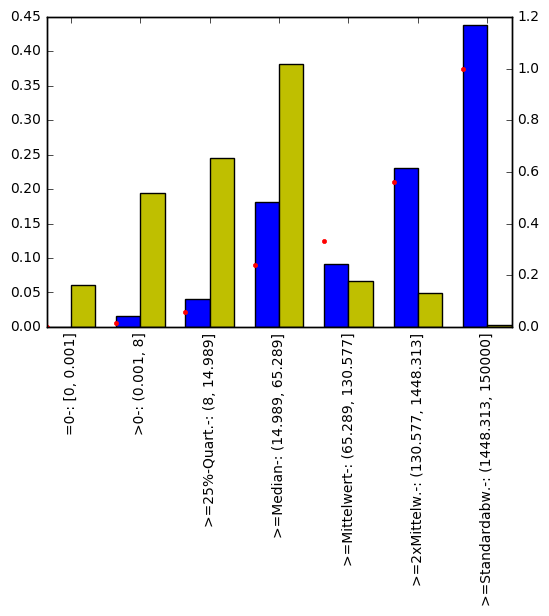

In [789]:
plt.show()

In [231]:
binEdgeUpTo=math.ceil(vFWVB_h['W0'].mean())
print(binEdgeUpTo)

66


In [20]:
numOfBinsUpTo=10

In [21]:
binSpanUpto=math.floor(binEdgeUpTo/numOfBinsUpTo)
print(binSpanUpto)

6


In [22]:
rangeUpTo=range(0,binEdgeUpTo,binSpanUpto) 
edgesUpTo=[i for i in rangeUpTo]
#edgesUpTo.append(65)
print(edgesUpTo) #[[

[0, 6, 12, 18, 24, 30, 36, 42, 48, 54, 60]


In [23]:
labelsUpTo = [ "{0} - {1}".format(i, i + binSpanUpto-1 ) for i in rangeUpTo]
print(labelsUpTo)

['0 - 5', '6 - 11', '12 - 17', '18 - 23', '24 - 29', '30 - 35', '36 - 41', '42 - 47', '48 - 53', '54 - 59', '60 - 65']


In [24]:
plt.close('all')
plt.figure()

In [25]:
ax=vFWVB_h.plot.hist(x=vFWVB_h['W0'],bins=edgesUpTo
         #,range=(edgesUpTo[0],edgesUpTo[-1]+binSpanUpto)
         ,label=labelsUpTo
        # ,cumulative=True
        )

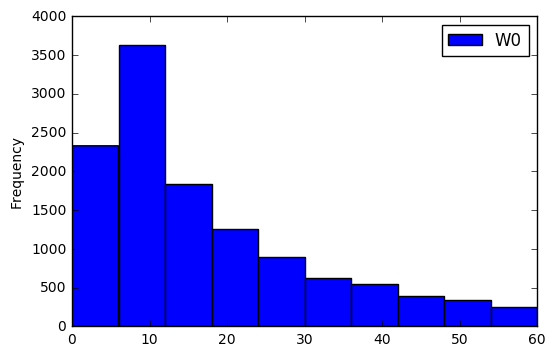

In [26]:
plt.show()

In [157]:
plt.close('all')
plt.figure()
ax=plt.subplot() #ax=plt.gca()

In [158]:
counts, bins, patches = ax.hist(x=vFWVB_h['W0']
                                 ,bins=edgesUpTo
         #,range=(edgesUpTo[0],edgesUpTo[-1]+binSpanUpto)
         ,label=labelsUpTo
        # ,cumulative=True
        )    

In [159]:
print(counts)

[  845.  1486.  3637.  1834.  1251.   901.   627.   549.   389.   343.
   248.]


In [160]:
vFWVB_h[(vFWVB_h['W0']>=edgesUpTo[0]) & (vFWVB_h['W0']<edgesUpTo[1])].count()

W0    845
dtype: int64

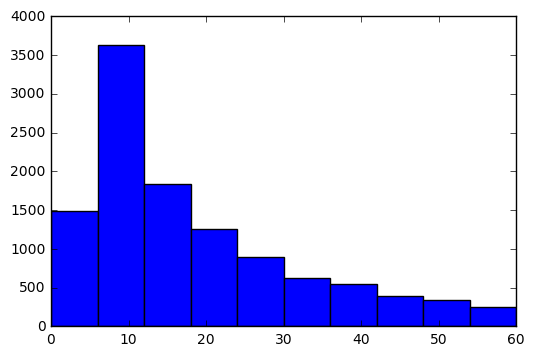

In [161]:
plt.show()

In [202]:
plt.close('all')
plt.figure()
ax=plt.subplot() #ax=plt.gca()

In [203]:
edgesUpTo=[0, 0.0001, 6, 12, 18, 24, 30, 36, 42, 48, 54, 60]

In [204]:
labelsUpTo=['=0', '>0 - 5', '6 - 11', '12 - 17', '18 - 23', '24 - 29', '30 - 35', '36 - 41', '42 - 47', '48 - 53', '54 - 59', '60 - 65']

In [205]:
counts, bins, patches = ax.hist(x=vFWVB_h['W0']
                                 ,bins=edgesUpTo
         #,range=(edgesUpTo[0],edgesUpTo[-1]+binSpanUpto)
         ,label=labelsUpTo
        # ,cumulative=True
        )    

In [206]:
# We'll color code by height, but you could use any scalar
fracs = counts.astype(float) / counts.sum()
print(fracs)

[ 0.06977704  0.12270851  0.30033031  0.15144509  0.10330306  0.07440132
  0.05177539  0.04533443  0.03212221  0.0283237   0.02047894]


In [207]:
from matplotlib import colors
#from matplotlib.ticker import PercentFormatter

In [208]:
norm = colors.Normalize(fracs.min(), fracs.max())
print(norm)

In [209]:
# Now, we'll loop through our objects and set the color of each accordingly
for thisfrac, thispatch in zip(fracs, patches):
    color = plt.cm.PuBu(norm(thisfrac))
    thispatch.set_facecolor(color)


In [210]:
ax.set_xticks(bins)

In [212]:
# Label the raw counts and the percentages below the x-axis...
bin_centers = 0.5 * np.diff(bins) + bins[:-1]
for count, x in zip(counts, bin_centers):
    txt="{0:d}".format(int(count))
    # Label the raw counts
    ax.annotate(txt #str(count)
                , xy=(x, 0), xycoords=('data', 'axes fraction')
    #   , xytext=(0, -18), textcoords='offset points', va='top', ha='center'
               )

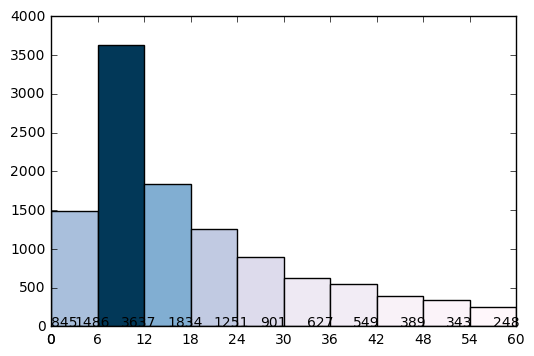

In [213]:
plt.show()

In [145]:
print(counts)

[  845.  1486.  3637.  1834.  1251.   901.   627.   549.   389.   343.
   239.  1829.]


In [56]:
print(bins)

[  0.00000000e+00   1.00000000e-04   6.00000000e+00   1.20000000e+01
   1.80000000e+01   2.40000000e+01   3.00000000e+01   3.60000000e+01
   4.20000000e+01   4.80000000e+01   5.40000000e+01   6.00000000e+01]


In [38]:
xm.vVKNO.head(5)


,CONT,NAME,KTYP,fkCONT,fkKNOT,LFAKT,QM_EIN
0,MSH/PSE,K40086-A,QVAR,5038168934032900013,5498452708549742602,1,0
1,MSH/PSE,K40090-A,QKON,5038168934032900013,4907656556172397386,1,0
2,MSH/PSE,K40100-A,QKON,5038168934032900013,5276360638818671732,1,0
3,Rohrhof,K35322-A,QVAR,5090451068169492361,4981782902913107818,1,0
4,Rohrhof,K35334-A,QVAR,5090451068169492361,5042634543301781082,1,0


In [39]:
xm.vKNOT.head(5)

,NAME,BESCHREIBUNG,IDREFERENZ,CONT,CONT_VKNO,KTYP,LFAKT,QM_EIN,QVAR,QM,QM_min,QM_max,KVR,TE,TM,XKOR,YKOR,ZKOR,pk,tk
0,K25826,"Q = 0 m3/h; P = 8,9659 bar; H = 191,491 m",00270000000ccd6e,M-1-0-1,NaN,QKON,1,0,NaN,NaN,NaN,NaN,1,NaN,129.7,3462653.147,5480159.094,93.71,4611688057248940909,4611688057248940909
1,K19343,"Q = 0 m3/h; P = 2,2996 bar; H = 116,62 m",00270000000a6d94,M-1-0-1,NaN,QKON,1,0,NaN,NaN,NaN,NaN,2,NaN,59.2,3461423.997,5485264.123,92.78,4611700510609988221,4611700510609988221
2,K60374,"Q = 0 m3/h; P = 2,1035 bar; H = 120,485 m",002700010000cfb2,M-1-0-1,NaN,QKON,1,0,NaN,NaN,NaN,NaN,2,NaN,59.9,3464717.786,5485733.741,98.67,4611704445968211280,4611704445968211280
3,K69824,"Q = 0 m3/h; P = 6,4215 bar; H = 169,506 m",0027000100032cd4,M-1-0-1,NaN,QKON,1,0,NaN,NaN,NaN,NaN,1,NaN,128.9,3465360.43,5485842.441,99.52,4611704963801634216,4611704963801634216
4,K28251,"Q = 0 m3/h; P = 8,7069 bar; H = 188,21 m",KNO001674588B5B5FD741,M-1-0-1,NaN,QKON,1,0,NaN,NaN,NaN,NaN,1,NaN,126.5,3462736.76,5480661.308,93.53,4611712196058831040,4611712196058831040


In [40]:
xm.vKNOT[['NAME']].size

81835

In [41]:
xm.vKNOT[(xm.vKNOT['KTYP'].isin(['QKON']) & xm.vKNOT['QM_EIN'].astype(float)!=0) | xm.vKNOT['KTYP'].isin(['QVAR'])][[
                    'NAME'              
                   ,'CONT'
                   ,'CONT_VKNO' # vVKNO
                   ,'KTYP'
                   ,'LFAKT','QM_EIN','QVAR','QM','QM_min','QM_max'     
                   ,'KVR' 
                   ,'TE','TM'                   
    ]].sort_values(by=['CONT_VKNO','NAME'])

,NAME,CONT,CONT_VKNO,KTYP,LFAKT,QM_EIN,QVAR,QM,QM_min,QM_max,KVR,TE,TM
51603,K22799-A,M-1-0-1,BHW,QVAR,1,0,bBHW_VL,55.2,55.2,55.2,1,NaN,110
54347,K38389-A,M-1-0-1,Brühl,QVAR,1,0,bBrü_RL,-5.6,-5.6,-5.6,2,NaN,59.1
73575,K38391-A,M-1-0-1,Brühl,QVAR,1,0,bBrü_VL,5.6,5.6,5.6,1,NaN,110
8973,K6558-A,M-1-0-1,Coleman,QVAR,1,0,bCole_VL,23.5,23.5,23.5,1,NaN,120.4
12037,K6560-A,M-1-0-1,Coleman,QVAR,1,0,bCole_RL,-23.5,-23.5,-23.5,2,NaN,60
36030,K25408-A,M-1-0-1,EXPL,QVAR,1,0,bEXPL_RL,-13.8,-13.8,-13.8,2,NaN,59.3
27972,K25412-A,M-1-0-1,EXPL,QVAR,1,0,bEXPL_VL,13.8,13.8,13.8,1,NaN,110
81683,K23019-A,M-1-0-1,Elektrosdlg,QVAR,1,0,bElek_VL,2.6,2.6,2.6,1,NaN,110
60460,K23068-A,M-1-0-1,Elektrosdlg,QVAR,1,0,bElek_RL,-2.6,-2.6,-2.6,2,NaN,58.7
21362,K39518-A,M-1-0-1,MFH/PWF,QVAR,1,0,bPWF_RL,-19.0,-19.0,-19.0,2,NaN,59


In [42]:
xm.pRSLW.head()

,KA,BESCHREIBUNG,INDSLW,SLWKON,CONT,SWVT,BESCHREIBUNG_SWVT,W,W_min,W_max
0,MNF_RL_uW,MNF_RL_uW,1,NaN,Dreiecke Längsschnitt,MNF_RL_uW,Beschreibung Tabelle,10.213552,10.213552,10.213552
1,SIE_VL_oW,SIE_VL_oW,1,NaN,Dreiecke Längsschnitt,SIE_VL_oW,Beschreibung Tabelle,19.652060,19.652060,19.652060
2,MNF_VL_oA,MNF_VL_oA,1,NaN,Dreiecke Längsschnitt,MNF_VL_oA,Beschreibung Tabelle,19.184122,19.184122,19.184122
3,PWG_VL_D_uA,PWG_VL_D_uA,1,NaN,Dreiecke Längsschnitt,PWG_VL_D_uA,Beschreibung Tabelle,13.446720,13.446720,13.446720
4,PWF_RL_D_uW,PWF_RL_D_uW,1,NaN,Dreiecke Längsschnitt,PWF_RL_D_uW,Beschreibung Tabelle,10.576522,10.576522,10.576522


In [43]:
xm.dataFrames['NRCV'].columns

Index(['ABSWERT', 'DECPOINT', 'DELETED', 'FONT', 'GRAF', 'SELECT1', 'UNIT',
       'fkCONT', 'fkDE', 'fkDPGR_ROWS', 'pk', 'rk', 'tk'],
      dtype='object')

In [44]:
vDPGR=pd.merge(xm.dataFrames['DPGR'],xm.dataFrames['DPGR_BZ'],left_on='pk',right_on='fk')

In [45]:
vDPGR.columns

Index(['DELETED', 'DESCRIPTION', 'NAME', 'PERMISSION_FLAGS', 'SELECT1',
       'fkDE_x', 'pk_x', 'rk', 'tk', 'EXTERNAL_USE', 'LOCAL_USE', 'fk',
       'fkDE_y', 'pk_y'],
      dtype='object')

In [46]:
vDPGR=vDPGR[[
        # DPGR
        'NAME'
        # DPGR IDs
       ,'pk_x', 'tk'
        # DPGR_BZ        
    ]]

In [47]:
vDPGR.rename(columns={'pk_x':'pk'},inplace=True)

In [48]:
vDPGR=pd.merge(vDPGR,xm.dataFrames['DPGR_ROWS'],left_on='pk',right_on='fk')

In [49]:
vDPGR.columns

Index(['NAME', 'pk_x', 'tk_x', 'ADDEND', 'ATTRTYPE', 'CLIENT_FLAGS',
       'DATALENGTH', 'DATATYPE', 'DESCRIPTION', 'DEVIATION', 'EPKZ', 'FACTOR',
       'FLAGS', 'LOWER_LIMIT', 'NAME1', 'NAME2', 'NAME3', 'OBJTYPE',
       'OL3COMMAND', 'TITLE', 'UNIT', 'UPPER_LIMIT', 'fk', 'fkOBJTYPE', 'pk_y',
       'rkDPGR_ROWS', 'tk_y'],
      dtype='object')

In [50]:
vDPGR=vDPGR[[
        # DPGR
        'NAME'
        # DPGR_BZ   
        # DPGR_ROWS
       ,'OBJTYPE','NAME1','NAME2','NAME3','ATTRTYPE'
       ,'ADDEND','FACTOR','DEVIATION'
       ,'FLAGS','CLIENT_FLAGS'
       ,'DESCRIPTION','TITLE','UNIT' 
       ,'DATALENGTH', 'DATATYPE'
       ,'LOWER_LIMIT','UPPER_LIMIT'
       ,'OL3COMMAND','EPKZ'
        # DPGR IDs
       ,'pk_x', 'tk_x'  
       ,'fkOBJTYPE'
       # DPGR_ROWS IDs 
       ,'pk_y','tk_y'
    ]]

In [51]:
cDct=dict(zip(vDPGR,vDPGR))

In [52]:
vDPGR.rename(columns={'pk_x':'pk','tk':'tk','pk_y':'pkROWS','tk_y':'tkROWS'},inplace=True)

In [53]:
xm.dataFrames['DPGR_ROWS'].columns

Index(['ADDEND', 'ATTRTYPE', 'CLIENT_FLAGS', 'DATALENGTH', 'DATATYPE',
       'DESCRIPTION', 'DEVIATION', 'EPKZ', 'FACTOR', 'FLAGS', 'LOWER_LIMIT',
       'NAME1', 'NAME2', 'NAME3', 'OBJTYPE', 'OL3COMMAND', 'TITLE', 'UNIT',
       'UPPER_LIMIT', 'fk', 'fkOBJTYPE', 'pk', 'rkDPGR_ROWS', 'tk'],
      dtype='object')

In [54]:
vDPGR.head()

,NAME,OBJTYPE,NAME1,NAME2,NAME3,ATTRTYPE,ADDEND,FACTOR,DEVIATION,FLAGS,...,DATATYPE,LOWER_LIMIT,UPPER_LIMIT,OL3COMMAND,EPKZ,pk,tk_x,fkOBJTYPE,pkROWS,tkROWS
0,Generics,VENT,*,*,NaN,QM,0,1,0,1269,...,REAL,-1E+20,1E+20,NaN,2,4986173869667303713,4986173869667303713,-1,4613077773235745446,4613077773235745446
1,Generics,RPT1,*,NaN,NaN,XE,0,1,0,1077,...,REAL,-1E+20,1E+20,NaN,1,4986173869667303713,4986173869667303713,-1,4622571982422608915,4622571982422608915
2,Generics,FWES,*,*,NaN,DP,0,1,0,1061,...,REAL,-1E+20,1E+20,NaN,8,4986173869667303713,4986173869667303713,-1,4625681273315314323,4625681273315314323
3,Generics,BEVE,*,*,NaN,VLUFT,0,1,0,1077,...,REAL,-1E+20,1E+20,NaN,4,4986173869667303713,4986173869667303713,-1,4627828573307815175,4627828573307815175
4,Generics,RHYS,*,NaN,NaN,XE,0,1,0,1269,...,REAL,-1E+20,1E+20,NaN,1,4986173869667303713,4986173869667303713,-1,4636606707504507053,4636606707504507053


In [55]:
pd.merge(vDPGR,xm.dataFrames[vDPGR.apply(lambda row: row.OBJTYPE, axis=1)],left_on='fkOBJTYPE',right_on='pk')

TypeError: 'Series' objects are mutable, thus they cannot be hashed

In [ ]:
xm.vKNOT.columns

In [ ]:
sorted(xm.dataFrames.keys())